<a href="https://colab.research.google.com/github/TeachingWithAI/TAI/blob/main/Diffusion_models_teachers_material.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion models - teacher material

This is the supplementary material for teachers to help with the lesson on Diffusion models. It contains:
1. summary of the lesson.
2. Requirements and preparation.
3. Tips for assignment 1: noise to image.
4. Code to create your own noisy images.
5. Tips on the extra lesson on optical illusions.


## 1. Summary of the lesson


How do AI models generate images, music and videos? Behind it is a diffusion model that can generate **structure out of noise**. In this lesson you learn how it works.

Duration: 45 minutes
- Assignment 1: offline backward diffusion (15 min)
- Diffusion: How it works (20min)
- Play with online tool and optical illusions (10 min)

Learning goals:
- Understanding how AI models generate images with the diffusion mechanism


## 2. Requirements and preparation


Requirements:
- For this lesson the students need acces to a computer
with access to an image generation tool based on a diffusion model. Examples are: ChatGPT, Canva, ...

Preparation:
- Print the file: Assignment 1: offline diffusion for every group of 5/6 students. Print on A3 format.
- Provide heets with small circular stickers (adhesive dots) in colors black and white. The dots should cover the pixels in assignment one. If you print on A3, stickers with a diameter of 8mm should work.
Every student should get one sheet with black and one with white stickers.



## Tips on Assignment 1: Noise to image
Form groups of 5 or 6 students. Everyone receives a sheet printed with a noisy figure and a prompt written on top, as well as sheets of black and white stickers. You will create images from the prompt in 10 steps of 30 seconds. Every step you do the following:

Read the prompt and make some changes to the pixels such that it starts looking more like the prompt. If you do not know where to start, it sometimes helps to look through your eyelids for an already existing shape.
Do not draw lines, only fill/erase pixels with stickers.
At the end of the 30 seconds, give the sheet to your neighbour on the left.

After 10 rounds we collect all drawings in front of the classroom. Discuss the following questions:
- Do you recognize the images?
- How did you decide where to make changes?
- What differences and similarities do you notice between the examples of the same prompts?
- How do you imagine that a computer can create an image out of noise?

**Teachers notes:**

For Assignment 1 you need the following material.
- Per student one sheet of round black and white sticker dots.
- Print a sheet of noise and prompt sheet for each student Within the groups of 5-6 they should each have  a different sheet. But you can give the same 5/6 sheets to every group, as it is nice to compare different results for the same starting sheet. The sheets can be found in the folder: noise sheets.
- You can create your own noise squares and come up with your own promts. In the cell below you find the code to create a grey-scaled random noise square of pixels. You can vary the size by changing it from 28x28 to a size of your wish.

## 4. Code to create your own noisy images

Here we share the code that you can use to create your own images and add noise to them.

### Code to create random noise

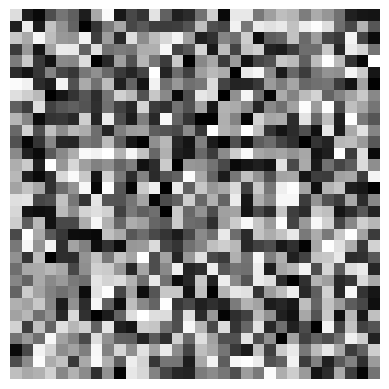

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 32x32 array of random values between 0 and 1
# This will represent the pixel intensities for a grayscale image
random_noise_image = np.random.rand(32, 32)

# Display the image using matplotlib with a grayscale colormap
plt.imshow(random_noise_image, cmap='gray')
# plt.title('32x32 Pixel Random Noise Image (Grayscale)')
plt.axis('off') # Hide the axes for a cleaner image display
plt.show()

### Task: draw a 32x32 pixel image of an apple:

In a similar way you can create your own images.

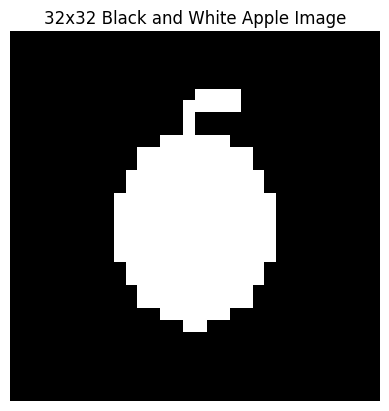

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 32x32 array of zeros (white background, assuming 0.0 is white for cmap='gray' with vmin=0, vmax=1)
apple_image = np.zeros((32, 32))

# Define some pixels to represent an apple (simplified drawing) for a 32x32 image
# Main body of the apple
apple_image[10:24, 11:21] = 1.0 # Larger central body
apple_image[12:22, 10:22] = 1.0 # Larger central body
apple_image[14:20, 9:23] = 1.0 # Larger central body

# Shaping the top of the apple
apple_image[9, 13:19] = 1.0
apple_image[10, 12:20] = 1.0

# Shaping the bottom of the apple
apple_image[24, 13:19] = 1.0
apple_image[25, 15:17] = 1.0

# Stem
apple_image[6:9, 15:16] = 1.0

# Small leaf (simplified)
apple_image[5:7, 16:20] = 1.0


# Display the image using matplotlib with a grayscale colormap
plt.imshow(apple_image, cmap='gray', vmin=0, vmax=1) # vmin/vmax ensure 0 is white and 1 is black
plt.title('32x32 Black and White Apple Image')
plt.axis('off') # Hide the axes for a cleaner image display
plt.show()

### How to draw pixel images
An other way to create pixel images, instead of defining them directly as a numpy array, is drawing them yourself at the website https://www.pixilart.com/draw#
There, you can download your image as a png file. In order to use that file here, you need to create an numpy array from this png file.

Here we add the code that we used to do this: https://colab.research.google.com/drive/1DkMj5QtHWND4o8s-vxoE7jbSJ4Iw60cj?usp=sharing

The result is that you can save an numpy array, e.g. 'guitar.npy'. You can upload that file here like this:

In [ ]:
guitar_image = np.load("guitar.npy")

### Function that adds noise to a given image.



In [ ]:
import numpy as np

def add_noise_numpy(x, t):
    """
    Adds noise to a NumPy array image based on a given noise level.
    Args:
        x (np.ndarray): The input image as a NumPy array.
        t (float): The noise level (between 0 and 1).
    Returns:
        np.ndarray: The noisy image.
    """
    return x * np.sqrt(1 - t) + np.random.randn(*x.shape) * np.sqrt(t)

print("Defined add_noise_numpy function.")

Defined add_noise_numpy function.


### Here we take an image and add noise in four steps. This can be used to illustrate forward diffusion.

In the second line, change the name to the name of the image you want to make noisy.

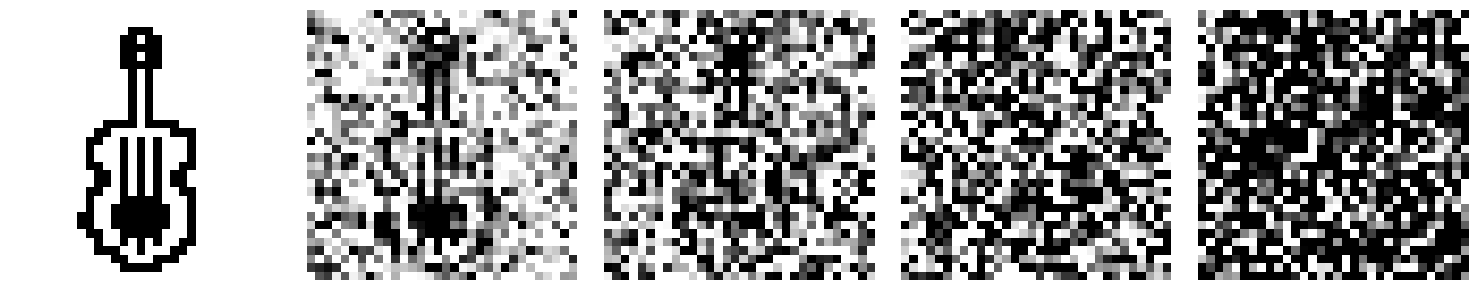

In [ ]:
import matplotlib.pyplot as plt

image_now = guitar_image # CHANGE THIS TO THE IMAGE YOU WANT TO MAKE NOISY

# Create a figure with five subplots
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

# Iterate five times to apply increasing levels of noise
for i in range(5):
    t = i / 4.0  # Calculate noise level from 0.0 to 1.0
    noisy_image = add_noise_numpy(image_now, t) # Apply noise using the defined function

    # Display the noisy image in the corresponding subplot
    axs[i].imshow(noisy_image, cmap='gray', vmin=0, vmax=1)
    #axs[i].set_title(f't={t:.2f}') # Add title with noise level
    axs[i].axis('off') # Turn off axes

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show() # Display the plot

### For Assignment 1 we use the image after adding two steps of noise. Here is the code to only print that image.

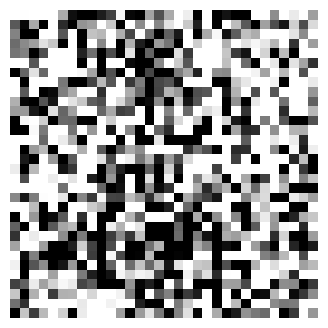

In [ ]:
import matplotlib.pyplot as plt

# Calculate the noise level for i=2
t_for_i2 = 2 / 4.0

# Apply noise to the binary_truck_image for t=0.50
noisy_image_i2 = add_noise_numpy(image_now, t_for_i2)

# Display the specific noisy image
plt.figure(figsize=(4, 4))
plt.imshow(noisy_image_i2, cmap='gray', vmin=0, vmax=1)
#plt.title(f'Noisy Truck Image (t={t_for_i2:.2f})')
plt.axis('off')
plt.show()

### If you want to work with circular stickers, you can make the pixils round with this code.

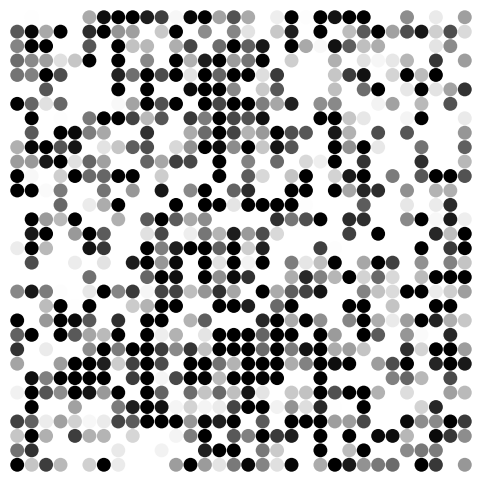

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure noisy_image_i3 is defined (from previous step)
# If it's not, you might need to re-run the previous cell or explicitly define it for this example
# For this demonstration, we'll assume noisy_image_i3 is already available from the previous execution.

# Get the dimensions of the image
rows, cols = noisy_image_i2.shape

# Create a grid of coordinates for each pixel
x, y = np.meshgrid(np.arange(cols), np.arange(rows))

# Flatten the arrays for scatter plot
x_flat = x.flatten()
y_flat = y.flatten()
colors_flat = noisy_image_i2.flatten()

plt.figure(figsize=(6, 6))
# Use scatter plot to draw circles for each 'pixel'
# s: size of the marker, chosen to make them appear as a contiguous grid if desired, or separated
# c: color, mapped from the image intensity
# cmap: colormap (e.g., 'gray' for grayscale)
# marker: 'o' for circle
# edgecolors: 'none' to remove borders around circles
plt.scatter(x_flat, y_flat, c=colors_flat, s=100, cmap='gray', marker='o', edgecolors='none', vmin=0, vmax=1)

#plt.title('Noisy Truck Image with Round Pixels')
plt.gca().set_aspect('equal', adjustable='box') # Maintain aspect ratio
plt.xlim(-0.5, cols - 0.5) # Adjust limits to fit circles nicely
plt.ylim(rows - 0.5, -0.5) # Invert y-axis to match image origin (top-left)
plt.axis('off') # Hide axes
plt.show()

## 5. About the extra lesson on Optical Illusions

There is an extra lesson available where the students can create their own optical illusions using a freely accasible colab notebook. As this code is a bit more technical, it helps to first play with it yourself. It's really fun!